In [1]:
import pandas as pd
import numpy as np

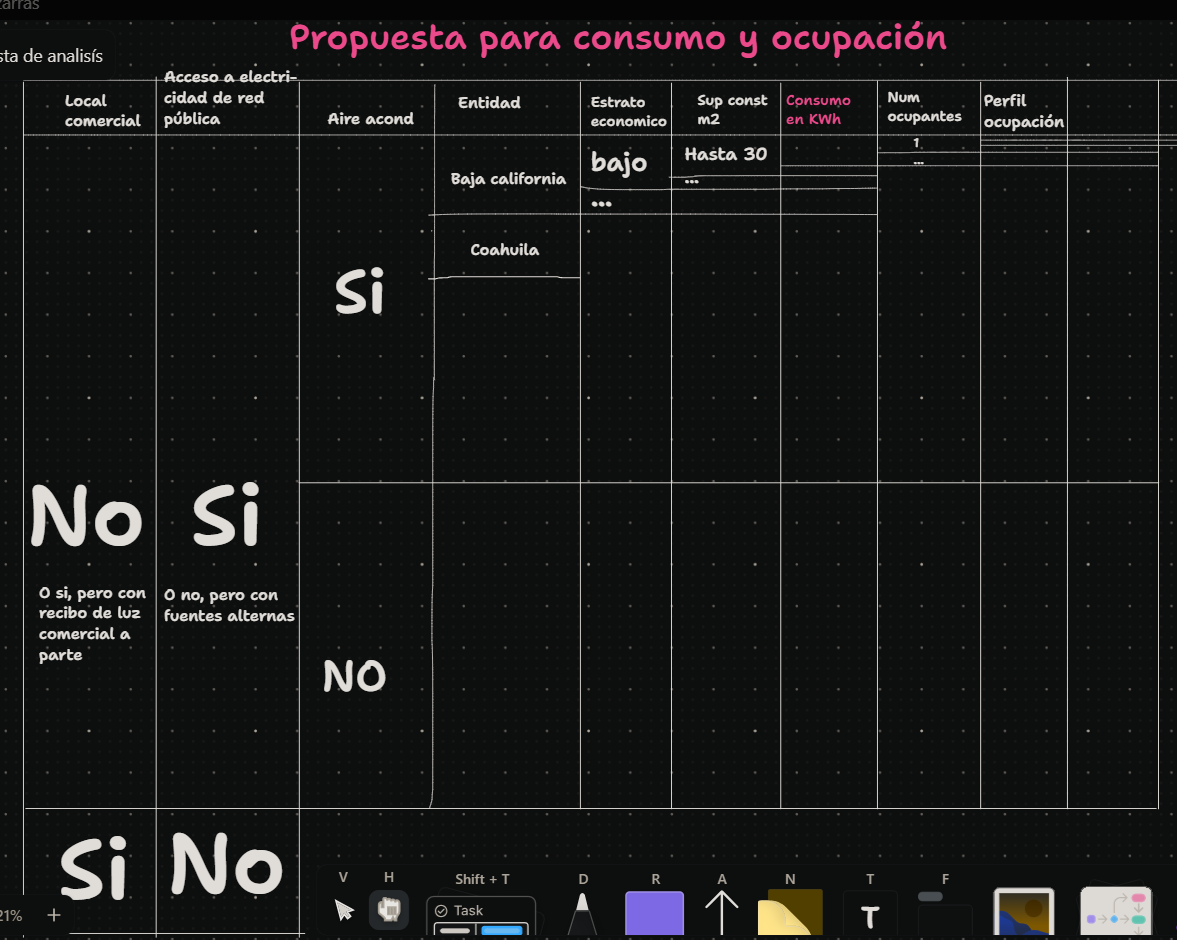

Las variables que necesitamos son:

**De ENCEVI** 
- "folio"
- local comercial
    - "local_com"
        - 1 = Si
        - 2 = No
    - Recibo de luz del local "elect_loc"
        - 1 = Si
        - 2 = No
- Electricidad de red pública "electri"
    - 1 = Si
    - 2 = No
- Uso de aire acondicionado "uso_aire"
    - 1 = Si
    - 2 = No
- super_cons  
    - 1 = Hasta 30m²  
    - 2 = De 31 a 55m²  
    - 3 = De 56 a 75m²  
    - 4 = De 76 a 100m²  
    - 5 = De 101 a 150m²  
    - 6 = De 151 a 200m²  
    - 7 = 201 a más m²  
    - 9 = No sabe

**De VIVIENDA:**
- "folio"
- Factor de expansión semestral "factor_sem"
- Entidad "entidad"
    - Son 32 entidad, una por cada estado
- Estrato socioeconómico "est_socio"
    - 1 = Bajo
    - 2 = Medio bajo
    - 3 = Medio alto
    - 4 = Alto

**De HOGAR:**
- "folio"
- Número de integrantes del hogar "tot_integ"

**De CONSUMO:**
- folio "folioviv"
- Factor de expansión semestral "factor"
- Consumo en el perdiodo en kWh "bill_kwh_estimation"
- Periodo "bill_period"
    - bi-monthly
    - monthly	

## Importar ENCEVI y limpiar 

In [2]:
f="../data/ENCEVI_raw/3_encevi_2018_base_de_datos_csv/encevi.csv"
ENCEVI = pd.read_csv(f,
                     usecols = ["folio","super_cons","uso_aire",'local_com','elect_loc','electri',
                               'total_niv','super_cons','super_ter','tot_cuart',]
                    )
ENCEVI

,folio,total_niv,super_ter,super_cons,tot_cuart,electri,local_com,elect_loc,uso_aire
0,1,2,3,7,11,1,2,,2
1,2,1,3,3,6,1,2,,2
2,3,2,3,7,5,1,2,,2
3,4,1,3,4,6,1,2,,2
4,5,1,3,4,5,1,2,,2
...,...,...,...,...,...,...,...,...,...
28948,28949,1,9,9,3,1,2,,2
28949,28950,1,9,9,2,1,2,,2
28950,28951,1,9,9,5,1,2,,2
28951,28952,1,6,4,4,1,2,,2


In [3]:
ENCEVI.dtypes

folio          int64
total_niv      int64
super_ter      int64
super_cons     int64
tot_cuart      int64
electri        int64
local_com     object
elect_loc     object
uso_aire      object
dtype: object

In [4]:
# Identificar columnas tipo objeto
columnas = ENCEVI.select_dtypes(include='object').columns

for col in columnas:
    # Reemplazar cadenas vacías o espacios con NaN
    ENCEVI[col] = ENCEVI[col].replace(r'^\s*$', np.nan, regex=True)
    
    # Intentar convertir a numérico (NaN si falla)
    ENCEVI[col] = pd.to_numeric(ENCEVI[col], errors='coerce')
    
    # Convertir a tipo entero que soporte NaN
    ENCEVI[col] = ENCEVI[col].astype('Int64')

for col in columnas:
    print(f"Distribución de valores en '{col}':")
    print(ENCEVI[col].value_counts(dropna=False))
    print("\n" + "-"*40 + "\n")


Distribución de valores en 'local_com':
local_com
2       26830
1        1847
<NA>      276
Name: count, dtype: Int64

----------------------------------------

Distribución de valores en 'elect_loc':
elect_loc
<NA>    27106
2        1085
1         762
Name: count, dtype: Int64

----------------------------------------

Distribución de valores en 'uso_aire':
uso_aire
2       23544
1        5225
<NA>      184
Name: count, dtype: Int64

----------------------------------------



In [5]:
ENCEVI.dtypes

folio         int64
total_niv     int64
super_ter     int64
super_cons    int64
tot_cuart     int64
electri       int64
local_com     Int64
elect_loc     Int64
uso_aire      Int64
dtype: object

In [6]:
# Verificar si hay índices duplicados
df = ENCEVI
duplicados = df.index.duplicated()

# Mostrar si existen
if duplicados.any():
    print("Hay índices duplicados.")
    # Mostrar los índices duplicados (opcional)
    print(df.index[duplicados])
else:
    print("No hay índices duplicados.")
df

No hay índices duplicados.


,folio,total_niv,super_ter,super_cons,tot_cuart,electri,local_com,elect_loc,uso_aire
0,1,2,3,7,11,1,2,<NA>,2
1,2,1,3,3,6,1,2,<NA>,2
2,3,2,3,7,5,1,2,<NA>,2
3,4,1,3,4,6,1,2,<NA>,2
4,5,1,3,4,5,1,2,<NA>,2
...,...,...,...,...,...,...,...,...,...
28948,28949,1,9,9,3,1,2,<NA>,2
28949,28950,1,9,9,2,1,2,<NA>,2
28950,28951,1,9,9,5,1,2,<NA>,2
28951,28952,1,6,4,4,1,2,<NA>,2


## Importar VIVIENDA y limpiar 

In [7]:
f="../data/ENCEVI_raw/3_encevi_2018_base_de_datos_csv/vivienda.csv"
VIVIENDA = pd.read_csv(f,
                     usecols = ["folio","factor_sem","entidad",'est_socio']
                    )
VIVIENDA

,folio,est_socio,factor_sem,entidad
0,1,3,373,1
1,2,3,373,1
2,3,3,373,1
3,4,3,373,1
4,5,3,373,1
...,...,...,...,...
28948,28949,2,382,32
28949,28950,2,382,32
28950,28951,2,382,32
28951,28952,2,382,32


In [8]:
Total_viviendas_original = VIVIENDA.factor_sem.sum()
Total_viviendas_original

np.int64(33162148)

In [9]:
VIVIENDA.dtypes

folio         int64
est_socio     int64
factor_sem    int64
entidad       int64
dtype: object

In [10]:
columnas = ["est_socio","entidad"]

for col in columnas:
    print(f"Distribución de valores en '{col}':")
    print(VIVIENDA[col].value_counts(dropna=False))
    print("\n" + "-"*40 + "\n")

Distribución de valores en 'est_socio':
est_socio
2    15126
3     5884
1     5505
4     2438
Name: count, dtype: int64

----------------------------------------

Distribución de valores en 'entidad':
entidad
27    976
25    967
11    957
29    939
20    936
24    933
32    932
1     926
23    925
16    921
7     920
10    917
15    911
19    910
22    910
18    909
21    908
31    906
28    902
4     895
6     891
13    891
17    890
26    887
3     886
8     874
14    873
9     868
5     863
12    859
30    842
2     829
Name: count, dtype: int64

----------------------------------------



In [11]:
# Verificar si hay índices duplicados
df = VIVIENDA
duplicados = df.index.duplicated()

# Mostrar si existen
if duplicados.any():
    print("Hay índices duplicados.")
    # Mostrar los índices duplicados (opcional)
    print(df.index[duplicados])
else:
    print("No hay índices duplicados.")
df

No hay índices duplicados.


,folio,est_socio,factor_sem,entidad
0,1,3,373,1
1,2,3,373,1
2,3,3,373,1
3,4,3,373,1
4,5,3,373,1
...,...,...,...,...
28948,28949,2,382,32
28949,28950,2,382,32
28950,28951,2,382,32
28951,28952,2,382,32


## Importar HOGAR y limpiar 

In [12]:
f="../data/ENCEVI_raw/3_encevi_2018_base_de_datos_csv/hogar.csv"
HOGAR = pd.read_csv(f,
                     usecols = ["folio","tot_integ"]
                    )
HOGAR

,folio,tot_integ
0,1,1
1,2,4
2,3,4
3,4,1
4,5,2
...,...,...
28948,28949,4
28949,28950,3
28950,28951,2
28951,28952,4


In [13]:
HOGAR.dtypes

folio        int64
tot_integ    int64
dtype: object

In [14]:
columnas = ["tot_integ"]

for col in columnas:
    print(f"Distribución de valores en '{col}':")
    print(HOGAR[col].value_counts(dropna=False))
    print("\n" + "-"*40 + "\n")

Distribución de valores en 'tot_integ':
tot_integ
4     6702
3     5716
2     5183
5     4569
1     2883
6     2074
7      887
8      463
9      218
10     138
11      58
12      24
13      14
14      10
15       5
16       3
19       3
23       1
22       1
17       1
Name: count, dtype: int64

----------------------------------------



In [15]:
# Verificar si hay índices duplicados
df = HOGAR
duplicados = df.index.duplicated()

# Mostrar si existen
if duplicados.any():
    print("Hay índices duplicados.")
    # Mostrar los índices duplicados (opcional)
    print(df.index[duplicados])
else:
    print("No hay índices duplicados.")
df

No hay índices duplicados.


,folio,tot_integ
0,1,1
1,2,4
2,3,4
3,4,1
4,5,2
...,...,...
28948,28949,4
28949,28950,3
28950,28951,2
28951,28952,4


## Importar CONSUMO y limpiar 

In [16]:
f = "../data/ENCEVI_Hernandez/encevi_result_db_041722.csv"
CONSUMO = pd.read_csv(f,
                     usecols = ["folioviv","factor","bill_kwh_estimation","bill_days", "munic_name"]
                    )
CONSUMO.rename(columns={"folioviv": "folio",
                        # "factor": "factor_sem"
                       }
               , inplace=True)

CONSUMO

,folio,factor,bill_days,munic_name,bill_kwh_estimation
0,1,373,62,Aguascalientes,113.802301
1,2,373,30,Aguascalientes,128.896444
2,3,373,30,Aguascalientes,228.645610
3,4,373,30,Aguascalientes,167.110992
4,5,373,30,Aguascalientes,207.517844
...,...,...,...,...,...
20573,28941,382,62,Tepetongo,156.404354
20574,28943,382,60,Tepetongo,41.689786
20575,28945,382,59,Tepetongo,77.180962
20576,28948,382,30,Tepetongo,245.776231


In [17]:
CONSUMO.dtypes

folio                    int64
factor                   int64
bill_days                int64
munic_name              object
bill_kwh_estimation    float64
dtype: object

In [18]:
# Verificar si hay índices duplicados
df = CONSUMO
duplicados = df.index.duplicated()

# Mostrar si existen
if duplicados.any():
    print("Hay índices duplicados.")
    # Mostrar los índices duplicados (opcional)
    print(df.index[duplicados])
else:
    print("No hay índices duplicados.")
df

No hay índices duplicados.


,folio,factor,bill_days,munic_name,bill_kwh_estimation
0,1,373,62,Aguascalientes,113.802301
1,2,373,30,Aguascalientes,128.896444
2,3,373,30,Aguascalientes,228.645610
3,4,373,30,Aguascalientes,167.110992
4,5,373,30,Aguascalientes,207.517844
...,...,...,...,...,...
20573,28941,382,62,Tepetongo,156.404354
20574,28943,382,60,Tepetongo,41.689786
20575,28945,382,59,Tepetongo,77.180962
20576,28948,382,30,Tepetongo,245.776231


## Unir ENCEVI, VIVIENDA y HOGAR

In [19]:
print(f'''
ENCEVI tiene {len(ENCEVI):,.0f} folios
VIVIENDA tiene {len(VIVIENDA):,.0f} folios
HOGAR tiene {len(HOGAR):,.0f} folios
Todos tienen el mismo numero de datos
''')



ENCEVI tiene 28,953 folios
VIVIENDA tiene 28,953 folios
HOGAR tiene 28,953 folios
Todos tienen el mismo numero de datos



In [20]:
#Los unimos en un solo df
ENCEVI_VI_HO = pd.concat([ENCEVI, VIVIENDA.drop(columns=["folio"]), HOGAR.drop(columns=["folio"])], axis=1).copy()
ENCEVI_VI_HO

,folio,total_niv,super_ter,super_cons,tot_cuart,electri,local_com,elect_loc,uso_aire,est_socio,factor_sem,entidad,tot_integ
0,1,2,3,7,11,1,2,<NA>,2,3,373,1,1
1,2,1,3,3,6,1,2,<NA>,2,3,373,1,4
2,3,2,3,7,5,1,2,<NA>,2,3,373,1,4
3,4,1,3,4,6,1,2,<NA>,2,3,373,1,1
4,5,1,3,4,5,1,2,<NA>,2,3,373,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28948,28949,1,9,9,3,1,2,<NA>,2,2,382,32,4
28949,28950,1,9,9,2,1,2,<NA>,2,2,382,32,3
28950,28951,1,9,9,5,1,2,<NA>,2,2,382,32,2
28951,28952,1,6,4,4,1,2,<NA>,2,2,382,32,4


In [21]:
# Verificar si hay índices duplicados
df = ENCEVI_VI_HO
duplicados = df.index.duplicated()

# Mostrar si existen
if duplicados.any():
    print("Hay índices duplicados.")
    # Mostrar los índices duplicados (opcional)
    print(df.index[duplicados])
else:
    print("No hay índices duplicados.")
df

No hay índices duplicados.


,folio,total_niv,super_ter,super_cons,tot_cuart,electri,local_com,elect_loc,uso_aire,est_socio,factor_sem,entidad,tot_integ
0,1,2,3,7,11,1,2,<NA>,2,3,373,1,1
1,2,1,3,3,6,1,2,<NA>,2,3,373,1,4
2,3,2,3,7,5,1,2,<NA>,2,3,373,1,4
3,4,1,3,4,6,1,2,<NA>,2,3,373,1,1
4,5,1,3,4,5,1,2,<NA>,2,3,373,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28948,28949,1,9,9,3,1,2,<NA>,2,2,382,32,4
28949,28950,1,9,9,2,1,2,<NA>,2,2,382,32,3
28950,28951,1,9,9,5,1,2,<NA>,2,2,382,32,2
28951,28952,1,6,4,4,1,2,<NA>,2,2,382,32,4


In [22]:
ENCEVI_VI_HO.to_parquet("../data/modificado/ENCEVI_VI_HO.parquet", index=False)

In [23]:
ENCEVI_VI_HO['uso_aire'].value_counts()

uso_aire
2    23544
1     5225
Name: count, dtype: Int64

## Unir ENCEVI_VI_HO y CONSUMO

In [24]:
CONSUMO.set_index('folio',inplace=True)
ENCEVI_VI_HO.set_index('folio',inplace=True)

In [25]:
ENCEVI_VI_HO.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28953 entries, 1 to 28953
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   total_niv   28953 non-null  int64
 1   super_ter   28953 non-null  int64
 2   super_cons  28953 non-null  int64
 3   tot_cuart   28953 non-null  int64
 4   electri     28953 non-null  int64
 5   local_com   28677 non-null  Int64
 6   elect_loc   1847 non-null   Int64
 7   uso_aire    28769 non-null  Int64
 8   est_socio   28953 non-null  int64
 9   factor_sem  28953 non-null  int64
 10  entidad     28953 non-null  int64
 11  tot_integ   28953 non-null  int64
dtypes: Int64(3), int64(9)
memory usage: 3.0 MB


In [26]:
CONSUMO.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 1 to 28951
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   factor               20578 non-null  int64  
 1   bill_days            20578 non-null  int64  
 2   munic_name           20578 non-null  object 
 3   bill_kwh_estimation  20508 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 803.8+ KB


In [27]:
ENCEVI_VI_HO_CONSUMO = CONSUMO.join(ENCEVI_VI_HO, how='inner')
ENCEVI_VI_HO_CONSUMO.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20578 entries, 1 to 28951
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   factor               20578 non-null  int64  
 1   bill_days            20578 non-null  int64  
 2   munic_name           20578 non-null  object 
 3   bill_kwh_estimation  20508 non-null  float64
 4   total_niv            20578 non-null  int64  
 5   super_ter            20578 non-null  int64  
 6   super_cons           20578 non-null  int64  
 7   tot_cuart            20578 non-null  int64  
 8   electri              20578 non-null  int64  
 9   local_com            20578 non-null  Int64  
 10  elect_loc            1345 non-null   Int64  
 11  uso_aire             20578 non-null  Int64  
 12  est_socio            20578 non-null  int64  
 13  factor_sem           20578 non-null  int64  
 14  entidad              20578 non-null  int64  
 15  tot_integ            20578 non-null  int6

In [28]:
# Verificar si hay índices duplicados
duplicados = ENCEVI_VI_HO_CONSUMO.index.duplicated()

# Mostrar si existen
if duplicados.any():
    print("Por egluna razón índices duplicados.")
    # Mostrar los índices duplicados (opcional)
    print(ENCEVI_VI_HO_CONSUMO.index[duplicados])
else:
    print("No, hay índices duplicados.")


Por egluna razón índices duplicados.
Index([1618, 3563, 5456, 6535, 7810, 10126, 11700, 16915, 19734], dtype='int64', name='folio')


In [29]:
# Filtrar todas las filas que tienen un índice duplicado
duplicados_todos = ENCEVI_VI_HO_CONSUMO.loc[CONSUMO.index.isin(CONSUMO.index[CONSUMO.index.duplicated()])]

# Mostrar el resultado
print(duplicados_todos)

       factor  bill_days                munic_name  bill_kwh_estimation  \
folio                                                                     
1618      927         63        Playas de Rosarito           215.961813   
1618      927         63        Playas de Rosarito           215.961813   
3563     1024         60                     Acuna           141.056485   
3563     1024         60                     Acuna           141.056485   
5456     1153         63          Tuxtla Gutierrez            77.369247   
5456     1153         63          Tuxtla Gutierrez            77.369247   
6535      876         57                    Juarez           179.191649   
6535      876         57                    Juarez           179.191649   
7810     2989         30                Cuauhtemoc           118.226987   
7810     2989         30                Cuauhtemoc           118.226987   
10126     672         63  Huitzuco de los Figueroa            96.992678   
10126     672         63 

In [30]:
VIVIENDA.factor_sem.min()

np.int64(124)

In [31]:
duplicados = ENCEVI_VI_HO_CONSUMO.loc[ENCEVI_VI_HO_CONSUMO.index.duplicated(keep=False)]
# Agrupar por el índice
grupo = duplicados.groupby(duplicados.index)

# Función para verificar si las filas dentro de un grupo son idénticas
def son_identicos(df):
    return (df.nunique() == 1).all()

# Aplicarlo a todos los grupos, si es True entonces son identicos
grupo.apply(son_identicos)

folio
1618     False
3563     False
5456     False
6535     False
7810     False
10126    False
11700    False
16915    False
19734    False
dtype: bool

In [32]:
# Mantener solo la primera aparición de cada índice
ENCEVI_VI_HO_CONSUMO = ENCEVI_VI_HO_CONSUMO[~ENCEVI_VI_HO_CONSUMO.index.duplicated(keep='first')]


In [33]:
# Verificar si hay índices duplicados
duplicados = ENCEVI_VI_HO_CONSUMO.index.duplicated()

# Mostrar si existen
if duplicados.any():
    print("Por egluna razón índices duplicados.")
    # Mostrar los índices duplicados (opcional)
    print(ENCEVI_VI_HO_CONSUMO.index[duplicados])
else:
    print("No, hay índices duplicados.")


No, hay índices duplicados.


In [34]:
ENCEVI_VI_HO_CONSUMO

,factor,bill_days,munic_name,bill_kwh_estimation,total_niv,super_ter,super_cons,tot_cuart,electri,local_com,elect_loc,uso_aire,est_socio,factor_sem,entidad,tot_integ
folio,,,,,,,,,,,,,,,,
1,373,62,Aguascalientes,113.802301,2,3,7,11,1,2,<NA>,2,3,373,1,1
2,373,30,Aguascalientes,128.896444,1,3,3,6,1,2,<NA>,2,3,373,1,4
3,373,30,Aguascalientes,228.645610,2,3,7,5,1,2,<NA>,2,3,373,1,4
4,373,30,Aguascalientes,167.110992,1,3,4,6,1,2,<NA>,2,3,373,1,1
5,373,30,Aguascalientes,207.517844,1,3,4,5,1,2,<NA>,2,3,373,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28941,382,62,Tepetongo,156.404354,1,9,9,4,1,2,<NA>,2,2,382,32,5
28943,382,60,Tepetongo,41.689786,1,6,2,3,1,2,<NA>,2,2,382,32,4
28945,382,59,Tepetongo,77.180962,1,9,9,4,1,2,<NA>,2,2,382,32,5


In [35]:
viviendas_ENCEVI_VI_HO_CONSUMO = ENCEVI_VI_HO_CONSUMO.factor_sem.sum()
viviendas_ENCEVI_VI_HO_CONSUMO

np.int64(22324238)

In [36]:
print(f"Se tiraron: {Total_viviendas_original - viviendas_ENCEVI_VI_HO_CONSUMO:,.0f} datos que equivalen al {round(100*(Total_viviendas_original - viviendas_ENCEVI_VI_HO_CONSUMO)/Total_viviendas_original,2)} %")

Se tiraron: 10,837,910 datos que equivalen al 32.68 %


In [38]:
ENCEVI_VI_HO_CONSUMO.to_parquet("../data/modificado/ENCEVI_VI_HO_CONSUMO.parquet", index=False)

In [37]:
#Se verifica que al unir ambos dataframes el factor de expansion sea el mismo
(viviendas_ENCEVI_VI_HO_CONSUMO.factor-viviendas_ENCEVI_VI_HO_CONSUMO.factor).plot()

AttributeError: 'numpy.int64' object has no attribute 'factor'